# VIF Critic Training v4 — Diagnostic-First + Default LR Finder

This notebook follows the v2 diagnostic workflow and adds per-model LR finder runs
for the active ordinal heads (CORAL/CORN/EMD/SoftOrdinal).


# Config

In [1]:
from pathlib import Path

import json
import os

import yaml


def _deep_update(base, updates):
    for key, value in updates.items():
        if isinstance(base.get(key), dict) and isinstance(value, dict):
            _deep_update(base[key], value)
        else:
            base[key] = value
    return base


# Resolve repo root for config lookup
_repo = Path.cwd()
while _repo != _repo.parent and not (_repo / "config" / "vif.yaml").is_file():
    _repo = _repo.parent

_cfg_path = _repo / "config" / "vif.yaml"
if not _cfg_path.is_file():
    raise FileNotFoundError(f"Could not locate config file: {_cfg_path}")

_vif_cfg = yaml.safe_load(_cfg_path.read_text())
_training_defaults = _vif_cfg["training"]
_scheduler_defaults = _training_defaults["scheduler"]
_lr_finder_defaults = _training_defaults["lr_finder"]

lr_finder_cfg = {
    "start_lr": _lr_finder_defaults["start_lr"],
    "end_lr": _lr_finder_defaults["end_lr"],
    "num_iter": _lr_finder_defaults["num_iter"],
    "output_dir": "models/vif/lr_find_ordinal_v4",
}
if "max_selected_lr" in _lr_finder_defaults:
    lr_finder_cfg["max_selected_lr"] = _lr_finder_defaults["max_selected_lr"]

CONFIG = {
    # Encoder
    "encoder_model": "nomic-ai/nomic-embed-text-v1.5",
    "trust_remote_code": True,
    "truncate_dim": 256,  # Matryoshka truncation (MTEB 61.04 @ 256d)
    "text_prefix": "classification: ",  # Required task prefix for nomic models
    # Models to compare (previous 4 frontier runs + CDW-CE alpha sweep)
    "models_to_train": [
        "CORAL",
        "CORN",
        "EMD",
        "SoftOrdinal",
        "CDWCE_a2",
        "CDWCE_a3",
        "CDWCE_a5",
    ],
    "model_overrides": {},
    # Model
    "hidden_dim": 64,
    "dropout": 0.3,
    # Optimizer / training (sourced from config/vif.yaml)
    "learning_rate": _training_defaults["learning_rate"],
    "weight_decay": _training_defaults["weight_decay"],
    "batch_size": _training_defaults["batch_size"],
    "epochs": _training_defaults["epochs"],
    # Early stopping
    "early_stopping_patience": _training_defaults["early_stopping"]["patience"],
    "early_stopping_min_delta": _training_defaults["early_stopping"]["min_delta"],
    # LR scheduler
    "scheduler_factor": _scheduler_defaults["factor"],
    "scheduler_patience": _scheduler_defaults["patience"],
    "scheduler_min_lr": _scheduler_defaults["min_lr"],
    # State encoder
    "window_size": 1,
    # MC Dropout
    "mc_dropout_samples": 50,
    # Data split / training seeds
    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "split_seed": 2025,
    "model_seed": 2025,
    # LR finder config
    "use_lr_finder": True,
    "lr_finder": lr_finder_cfg,
    # Optional metadata for scripted runs
    "experiment_group": None,
    "skip_experiment_logging": False,
}

config_override_path = os.environ.get("TWINKL_VIF_NOTEBOOK_CONFIG")
if config_override_path:
    override_path = Path(config_override_path)
    if not override_path.is_absolute():
        override_path = (_repo / override_path).resolve()
    if not override_path.is_file():
        raise FileNotFoundError(f"Notebook override config not found: {override_path}")
    override_payload = yaml.safe_load(override_path.read_text()) or {}
    _deep_update(CONFIG, override_payload)

inline_overrides = os.environ.get("TWINKL_VIF_NOTEBOOK_OVERRIDES")
if inline_overrides:
    try:
        override_payload = json.loads(inline_overrides)
    except json.JSONDecodeError as exc:
        raise ValueError(
            "TWINKL_VIF_NOTEBOOK_OVERRIDES must be valid JSON"
        ) from exc
    _deep_update(CONFIG, override_payload)

legacy_seed = CONFIG.pop("seed", None)
if legacy_seed is not None:
    CONFIG.setdefault("split_seed", legacy_seed)
    CONFIG.setdefault("model_seed", legacy_seed)

CONFIG["split_seed"] = int(CONFIG["split_seed"])
CONFIG["model_seed"] = int(CONFIG["model_seed"])
CONFIG["models_to_train"] = list(CONFIG["models_to_train"])
CONFIG["model_overrides"] = dict(CONFIG.get("model_overrides", {}))

print("=" * 50)
print("CONFIGURATION")
print("=" * 50)
for key in [
    "encoder_model",
    "truncate_dim",
    "text_prefix",
    "hidden_dim",
    "dropout",
    "window_size",
    "learning_rate",
    "weight_decay",
    "batch_size",
    "epochs",
    "train_ratio",
    "val_ratio",
    "split_seed",
    "model_seed",
    "use_lr_finder",
    "experiment_group",
    "skip_experiment_logging",
]:
    print(f"  {key:<30s} {str(CONFIG.get(key)):>15s}")
print(f"  {'models_to_train':<30s} {CONFIG['models_to_train']}")
print("  model_overrides:")
print(json.dumps(CONFIG["model_overrides"], indent=2, sort_keys=True))
print("=" * 50)

CONFIGURATION
  encoder_model                  nomic-ai/nomic-embed-text-v1.5
  truncate_dim                               256
  text_prefix                    classification: 
  hidden_dim                                  64
  dropout                                    0.3
  window_size                                  1
  learning_rate                            0.001
  weight_decay                              0.01
  batch_size                                  16
  epochs                                       2
  train_ratio                                0.7
  val_ratio                                 0.15
  split_seed                                2025
  model_seed                                  11
  use_lr_finder                            False
  experiment_group               twinkl-681.2_post_split_frontier_rebaseline
  skip_experiment_logging                   True
  models_to_train                ['CORN']
  model_overrides:
{
  "CDWCE_a3": {
    "learning_rate": 0.0155222

# Import Libs

In [2]:
import os
import sys
from datetime import datetime
from functools import partial
from pathlib import Path

# Walk up to find project root (contains src/ and pyproject.toml)
_dir = Path.cwd()
while _dir != _dir.parent:
    if (_dir / "src").is_dir() and (_dir / "pyproject.toml").is_file():
        os.chdir(_dir)
        break
    _dir = _dir.parent
sys.path.insert(0, ".")

import json
import numpy as np
import polars as pl
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Ensure inline plotting in notebooks (prevents stale non-inline backend state)
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

from src.vif.dataset import (
    load_all_data,
    split_by_persona,
    merge_labels_and_entries,
    VIFDataset,
)
from src.vif.encoders import SBERTEncoder
from src.vif.state_encoder import StateEncoder
from src.vif.critic_ordinal import (
    CriticMLPCORAL,
    coral_loss_multi,
    CriticMLPCORN,
    corn_loss_multi,
    CriticMLPEMD,
    emd_loss_multi,
    CriticMLPCDWCE,
    cdw_ce_loss_multi,
    CriticMLPSoftOrdinal,
    soft_ordinal_loss_multi,
)
from src.vif.eval import (
    build_ordinal_selection_candidate,
    discretize_predictions,
    evaluate_with_uncertainty,
    export_ordinal_output_artifact,
    format_results_table,
    is_better_ordinal_candidate,
    ordinal_selection_policy_summary,
)
from src.vif.lr_finder import run_lr_finder
from src.models.judge import SCHWARTZ_VALUE_ORDER

# Reproducibility
np.random.seed(CONFIG["model_seed"])
torch.manual_seed(CONFIG["model_seed"])
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(CONFIG["model_seed"])

# Device selection (v2-compatible)
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

print(f"Working directory: {os.getcwd()}")
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")
print(f"Schwartz dimensions: {len(SCHWARTZ_VALUE_ORDER)}")
print(f"Split seed: {CONFIG['split_seed']}")
print(f"Model seed: {CONFIG['model_seed']}")

Working directory: /Users/desmondchoy/Projects/twinkl
Device: mps
PyTorch: 2.9.1
Schwartz dimensions: 10
Split seed: 2025
Model seed: 11


/Users/desmondchoy/Projects/twinkl/.venv/lib/python3.12/site-packages/torch_lr_finder/lr_finder.py:5: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# Section 1: Data Quality Audit (Issue #10)

**Issue #10 — Class Imbalance:**: Most Schwartz dimensions are neutral-dominated.
The model may learn to predict `0` for everything and still achieve high accuracy.
This section quantifies the imbalance and flags dimensions that may be unlearnable.

* `labels_df` - judge-assigned alignment scores
* `entries_df` - journal text

In [3]:
labels_df, entries_df = load_all_data()
merged_df = merge_labels_and_entries(labels_df, entries_df)

print(f"Labels shape:  {labels_df.shape}")
print(f"Entries shape: {entries_df.shape}")
print(f"Merged shape:  {merged_df.shape}")
print(f"Unique personas: {merged_df.select('persona_id').n_unique()}")


Labels shape:  (1460, 15)
Entries shape: (1460, 8)
Merged shape:  (1460, 21)
Unique personas: 180


In [4]:
labels_df.head().glimpse()

Rows: 5
Columns: 15
$ persona_id                     <str> '013d8101', '013d8101', '013d8101', '019235dc', '019235dc'
$ t_index                        <i64> 0, 1, 2, 0, 1
$ date                           <str> '2025-12-01', '2025-12-11', '2025-12-20', '2025-01-15', '2025-01-15'
$ alignment_vector         <list[i64]> [0, 0, 0, 0, 0, 1, 1, 0, 0, 0], [0, 0, 0, 0, 0, 1, 0, 0, 1, 0], [0, -1, 0, 0, 0, 1, 0, 0, 0, 0], [0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [0, 0, 0, 1, 0, 0, 0, 0, 1, 0]
$ alignment_self_direction       <i64> 0, 0, 0, 0, 0
$ alignment_stimulation          <i64> 0, 0, -1, 0, 0
$ alignment_hedonism             <i64> 0, 0, 0, 0, 0
$ alignment_achievement          <i64> 0, 0, 0, 1, 1
$ alignment_power                <i64> 0, 0, 0, 1, 0
$ alignment_security             <i64> 1, 1, 1, 0, 0
$ alignment_conformity           <i64> 1, 0, 0, 0, 0
$ alignment_tradition            <i64> 0, 0, 0, 0, 0
$ alignment_benevolence          <i64> 0, 1, 0, 0, 1
$ alignment_universalism         <i64> 0, 0,

In [5]:
entries_df.head().glimpse()

Rows: 5
Columns: 8
$ persona_id          <str> '013d8101', '013d8101', '013d8101', '019235dc', '019235dc'
$ persona_name        <str> 'Emma Lindqvist', 'Emma Lindqvist', 'Emma Lindqvist', 'Megan Torres', 'Megan Torres'
$ core_values   <list[str]> ['Security'], ['Security'], ['Security'], ['Achievement', 'Benevolence'], ['Achievement', 'Benevolence']
$ t_index             <i64> 0, 1, 2, 0, 1
$ date                <str> '2025-12-01', '2025-12-11', '2025-12-20', '2025-01-15', '2025-01-15'
$ initial_entry       <str> 'Parent-teacher conferences tomorrow and I keep running through the talking points in my head. Mikkel says I over-prepare but I would rather have every answer ready than stumble in front of someone asking about their child.', 'The school announced budget cuts today and there were some worried faces in the staff room. I felt steady, actually. My position is permanent and I have been here longer than most.', 'Mikkel brought up the idea of moving to Berlin again at dinner. His co

In [6]:
dropped_label_rows = labels_df.height - merged_df.height
if dropped_label_rows > 0:
    print(f"Dropped label rows after merge: {dropped_label_rows}")
    key_options = [
        ["persona_id", "t_index"],
        ["entry_id"],
    ]
    for keys in key_options:
        if all(k in labels_df.columns for k in keys) and all(
            k in merged_df.columns for k in keys
        ):
            labels_keys = labels_df.select(keys).unique()
            merged_keys = merged_df.select(keys).unique()
            dropped_keys = labels_keys.join(merged_keys, on=keys, how="anti")
            print(f"  Missing key rows by {keys}: {dropped_keys.height}")
            if dropped_keys.height > 0:
                print(dropped_keys.head(5))
            break

print(
    f"\nLabel columns: {[c for c in labels_df.columns if c.startswith('alignment_')]}"
)
print(
    f"\nEntry text columns: {[c for c in entries_df.columns if c not in labels_df.columns]}"
)


Label columns: ['alignment_vector', 'alignment_self_direction', 'alignment_stimulation', 'alignment_hedonism', 'alignment_achievement', 'alignment_power', 'alignment_security', 'alignment_conformity', 'alignment_tradition', 'alignment_benevolence', 'alignment_universalism']

Entry text columns: ['persona_name', 'core_values', 'initial_entry', 'nudge_text', 'response_text']


## Class Distribution per Dimension

In [7]:
n_dims = len(SCHWARTZ_VALUE_ORDER)
distribution = np.zeros((n_dims, 3), dtype=int)  # rows=dims, cols=[-1, 0, +1]
class_labels = [-1, 0, 1]

for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    col = f"alignment_{dim}"
    series = merged_df.select(col).to_series()
    for j, val in enumerate(class_labels):
        distribution[i, j] = int((series == val).sum())

# Compute imbalance ratios
imbalance_ratios = []
for i in range(n_dims):
    row = distribution[i]
    ratio = float("inf") if (row == 0).any() else row.max() / row.min()
    imbalance_ratios.append(ratio)

# Print table
print(f"{'Dimension':<20s} {'-1':>6s} {'0':>6s} {'+1':>6s} {'Ratio':>8s} {'Flag':>8s}")
print("-" * 55)
for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    flag = ">10x" if imbalance_ratios[i] > 10 else ""
    print(
        f"{dim:<20s} {distribution[i, 0]:>6d} {distribution[i, 1]:>6d} {distribution[i, 2]:>6d} {imbalance_ratios[i]:>8.1f} {flag:>8s}"
    )

neutral_pct = distribution[:, 1].sum() / distribution.sum() * 100
print(f"\nOverall neutral %: {neutral_pct:.1f}%")

Dimension                -1      0     +1    Ratio     Flag
-------------------------------------------------------
self_direction          204    859    397      4.2         
stimulation              51   1282    127     25.1     >10x
hedonism                117   1185    158     10.1     >10x
achievement              81    988    391     12.2     >10x
power                   121   1187    152      9.8         
security                136   1100    224      8.1         
conformity              126   1017    317      8.1         
tradition                58   1148    254     19.8     >10x
benevolence             120    912    428      7.6         
universalism             56   1246    158     22.2     >10x

Overall neutral %: 74.8%


Heatmap:

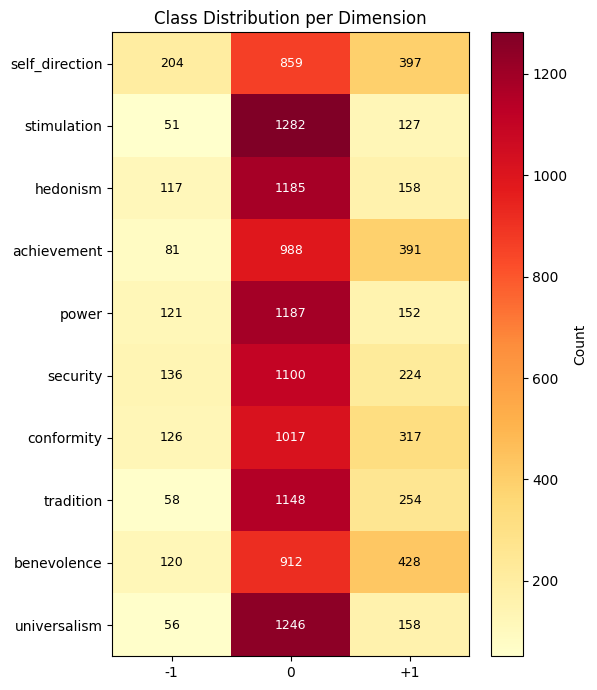

In [8]:
fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(distribution, cmap="YlOrRd", aspect="auto")
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(["-1", "0", "+1"])
ax.set_yticks(range(n_dims))
ax.set_yticklabels(SCHWARTZ_VALUE_ORDER)
ax.set_title("Class Distribution per Dimension")
for i in range(n_dims):
    for j in range(3):
        color = "white" if distribution[i, j] > distribution.max() * 0.6 else "black"
        ax.text(
            j,
            i,
            str(distribution[i, j]),
            ha="center",
            va="center",
            fontsize=9,
            color=color,
        )
plt.colorbar(im, ax=ax, label="Count")
plt.tight_layout()
plt.show()

Sparsity flags: Checking all dimensions where any class < 10 samples

In [9]:
MIN_SAMPLES = 10

print(f"{'Dimension':<20s} {'Min class':>10s} {'Min count':>10s} {'Status':>12s}")
print("-" * 55)
unlearnable = []
for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    min_idx = distribution[i].argmin()
    min_count = distribution[i, min_idx]
    min_class = class_labels[min_idx]
    status = "UNLEARNABLE" if min_count < MIN_SAMPLES else "OK"
    if min_count < MIN_SAMPLES:
        unlearnable.append(dim)
    print(f"{dim:<20s} {min_class:>10d} {min_count:>10d} {status:>12s}")

print(
    f"\nUnlearnable dims (any class < {MIN_SAMPLES} samples): {unlearnable if unlearnable else 'None'}"
)

Dimension             Min class  Min count       Status
-------------------------------------------------------
self_direction               -1        204           OK
stimulation                  -1         51           OK
hedonism                     -1        117           OK
achievement                  -1         81           OK
power                        -1        121           OK
security                     -1        136           OK
conformity                   -1        126           OK
tradition                    -1         58           OK
benevolence                  -1        120           OK
universalism                 -1         56           OK

Unlearnable dims (any class < 10 samples): None


# Section 2: Embedding Quality Probe (Issue #14)


**Issue #14 — Embedding Quality:** Are SBERT embeddings discriminative enough for value alignment? Does truncation lose information from long entries?

This section probes the encoder without retraining.

In [10]:
text_encoder = SBERTEncoder(
    CONFIG["encoder_model"],
    trust_remote_code=CONFIG["trust_remote_code"],
    truncate_dim=CONFIG["truncate_dim"],
    text_prefix=CONFIG["text_prefix"],
)
state_encoder = StateEncoder(
    text_encoder,
    window_size=CONFIG["window_size"],
)

print(f"Encoder: {text_encoder.model_name}")
print(f"Embedding dim: {text_encoder.embedding_dim}")
print(f"State dim: {state_encoder.state_dim}")

<All keys matched successfully>


Encoder: nomic-ai/nomic-embed-text-v1.5
Embedding dim: 256
State dim: 266


In [11]:
# Sample one random entry
rng = np.random.default_rng(CONFIG["split_seed"])
sample_idx = rng.integers(0, len(merged_df))
sample = merged_df.row(sample_idx, named=True)

print()
print("=" * 60)
print(f"RANDOM ENTRY VERIFICATION (row {sample_idx})")
print("=" * 60)
print(f"persona_id:    {sample['persona_id']}")
print(f"persona_name:  {sample.get('persona_name', 'N/A')}")
print(f"core_values:   {sample.get('core_values', 'N/A')}")
print(f"date:          {sample['date']}")
print(f"t_index:       {sample['t_index']}")

print()
print("--- initial_entry (first 200 chars) ---")
print(f"{(sample['initial_entry'] or '')[:200]}")
print()
print("--- nudge_text (first 200 chars) ---")
print(f"{(sample['nudge_text'] or '')[:200]}")
print()
print("--- response_text (first 200 chars) ---")
print(f"{(sample['response_text'] or '')[:200]}")


RANDOM ENTRY VERIFICATION (row 653)
persona_id:    70b51a5b
persona_name:  Meena Subramanian
core_values:   ['Power']
date:          2025-10-20
t_index:       6

--- initial_entry (first 200 chars) ---
Family WhatsApp group. Vikram posted photos of houses he and Priya are looking at in OMR — those new gated community flats near the IT corridor. Everyone started commenting, congratulating, sending em

--- nudge_text (first 200 chars) ---
What did the deleted messages say?

--- response_text (first 200 chars) ---
The first one asked why I'm always the last to know. The second one said something about respect. I deleted both because I knew Priya would read them too and it would become a whole thing.


Max context length: 8192 tokens

Token count statistics:
  Min:    18
  Mean:   200.8
  Median: 191.5
  P90:    342
  P95:    390
  Max:    709

Truncated entries: 0/1460 (0.0%)


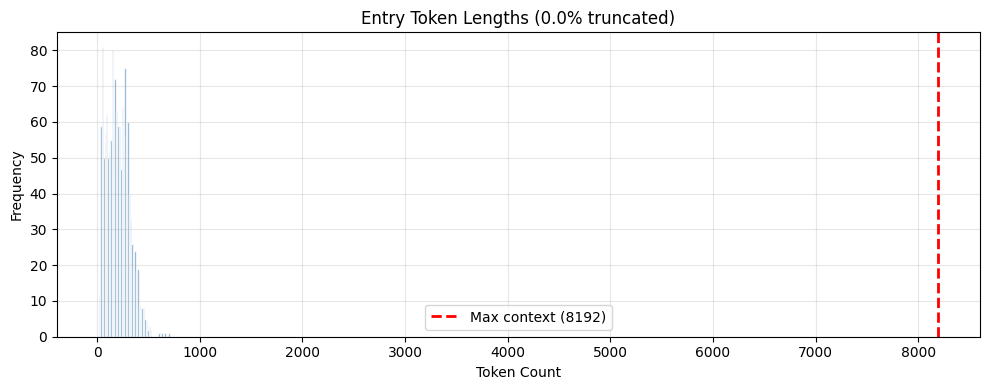

In [12]:
# Cell 2c — Entry length / truncation risk
tokenizer = text_encoder._model.tokenizer
max_seq_length = text_encoder._model.max_seq_length

all_texts = []
for row in merged_df.iter_rows(named=True):
    text = state_encoder.concatenate_entry_text(
        row["initial_entry"], row["nudge_text"], row["response_text"]
    )
    all_texts.append(text)

token_counts = []
for text in all_texts:
    tokens = tokenizer.encode(text, add_special_tokens=True)
    token_counts.append(len(tokens))

token_counts = np.array(token_counts)
n_truncated = (token_counts > max_seq_length).sum()
pct_truncated = n_truncated / len(token_counts) * 100

print(f"Max context length: {max_seq_length} tokens")
print(f"\nToken count statistics:")
print(f"  Min:    {token_counts.min()}")
print(f"  Mean:   {token_counts.mean():.1f}")
print(f"  Median: {np.median(token_counts):.1f}")
print(f"  P90:    {np.percentile(token_counts, 90):.0f}")
print(f"  P95:    {np.percentile(token_counts, 95):.0f}")
print(f"  Max:    {token_counts.max()}")
print(f"\nTruncated entries: {n_truncated}/{len(token_counts)} ({pct_truncated:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(token_counts, bins=50, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(
    max_seq_length,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Max context ({max_seq_length})",
)
ax.set_xlabel("Token Count")
ax.set_ylabel("Frequency")
ax.set_title(f"Entry Token Lengths ({pct_truncated:.1f}% truncated)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Section 3: Model & Training (Issue #12)


**Issue #12 — Overfitting Risk:** the model has a very high parameter-to-sample ratio. This section quantifies the risk and monitors the training/validation gap.

In [13]:
MODEL_CONFIGS = {
    "CORAL": {
        "class": CriticMLPCORAL,
        "loss_fn": coral_loss_multi,
        "is_ordinal": True,
    },
    "CORN": {
        "class": CriticMLPCORN,
        "loss_fn": corn_loss_multi,
        "is_ordinal": True,
    },
    "EMD": {
        "class": CriticMLPEMD,
        "loss_fn": emd_loss_multi,
        "is_ordinal": True,
    },
    "SoftOrdinal": {
        "class": CriticMLPSoftOrdinal,
        "loss_fn": soft_ordinal_loss_multi,
        "is_ordinal": True,
    },
    # CDW-CE alpha sweep
    "CDWCE_a2": {
        "class": CriticMLPCDWCE,
        "loss_fn": partial(cdw_ce_loss_multi, alpha=2),
        "is_ordinal": True,
    },
    "CDWCE_a3": {
        "class": CriticMLPCDWCE,
        "loss_fn": partial(cdw_ce_loss_multi, alpha=3),
        "is_ordinal": True,
    },
    "CDWCE_a5": {
        "class": CriticMLPCDWCE,
        "loss_fn": partial(cdw_ce_loss_multi, alpha=5),
        "is_ordinal": True,
    },
}


In [14]:
# Filter to active models
active_models = {
    k: dict(v) for k, v in MODEL_CONFIGS.items() if k in CONFIG["models_to_train"]
}

print(f"MODEL_CONFIGS defined: {list(MODEL_CONFIGS.keys())}")
print(f"models_to_train: {CONFIG['models_to_train']}")
print(f"Active models: {list(active_models.keys())}")


MODEL_CONFIGS defined: ['CORAL', 'CORN', 'EMD', 'SoftOrdinal', 'CDWCE_a2', 'CDWCE_a3', 'CDWCE_a5']
models_to_train: ['CORN']
Active models: ['CORN']


## Create datasets and dataloaders

In [15]:
print("Creating datasets (caching embeddings)...")
train_df, val_df, test_df = split_by_persona(
    labels_df,
    entries_df,
    train_ratio=CONFIG["train_ratio"],
    val_ratio=CONFIG["val_ratio"],
    seed=CONFIG["split_seed"],
)

train_dataset = VIFDataset(train_df, state_encoder, cache_embeddings=True)
val_dataset = VIFDataset(val_df, state_encoder, cache_embeddings=True)
test_dataset = VIFDataset(test_df, state_encoder, cache_embeddings=True)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False)

n_train = len(train_dataset)
n_val = len(val_dataset)
n_test = len(test_dataset)

print()
print("Split sizes:")
print(
    f"  Train: {n_train} samples ({train_df.select('persona_id').n_unique()} personas) -> {len(train_loader)} batches"
)
print(
    f"  Val:   {n_val} samples ({val_df.select('persona_id').n_unique()} personas) -> {len(val_loader)} batches"
)
print(
    f"  Test:  {n_test} samples ({test_df.select('persona_id').n_unique()} personas) -> {len(test_loader)} batches"
)

Creating datasets (caching embeddings)...


Batches:   0%|          | 0/32 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]

Batches:   0%|          | 0/7 [00:00<?, ?it/s]


Split sizes:
  Train: 1022 samples (125 personas) -> 64 batches
  Val:   217 samples (28 personas) -> 14 batches
  Test:  221 samples (27 personas) -> 14 batches


In [16]:
# Active model validation (v4 frontier set)
if not active_models:
    raise ValueError(
        f"No valid models in models_to_train={CONFIG['models_to_train']}. "
        f"Valid names: {list(MODEL_CONFIGS.keys())}"
    )

print(f"Using ordinal models: {', '.join(active_models.keys())}")


Using ordinal models: CORN


In [17]:
print(f"\n{'Model':<15s} {'Parameters':>12s} {'Output logits':>15s} {'Loss':>25s}")
print("-" * 70)
n_params = 0
for name, cfg in active_models.items():
    m = cfg["class"](
        input_dim=state_encoder.state_dim,
        hidden_dim=CONFIG["hidden_dim"],
        dropout=CONFIG["dropout"],
    )
    param_count = sum(param.numel() for param in m.parameters())
    n_params = max(n_params, param_count)
    n_out = m.fc_out.out_features
    loss_name = (
        cfg["loss_fn"].__class__.__name__
        if isinstance(cfg["loss_fn"], nn.Module)
        else getattr(
            cfg["loss_fn"],
            "__name__",
            getattr(cfg["loss_fn"], "func", cfg["loss_fn"]).__name__,
        )
    )
    print(f"{name:<15s} {param_count:>12,} {n_out:>15d} {loss_name:>25s}")
print("-" * 70)
print(f"\nMax parameters (for overfitting check): {n_params:,}")

# Overfitting risk check
param_sample_ratio = n_params / n_train
print(f"Parameters:       {n_params:,}")
print(f"Training samples: {n_train}")
print(f"Param/sample ratio: {param_sample_ratio:.1f}x")
print()
if param_sample_ratio > 100:
    print("SEVERE overfitting risk (>100x). Model will likely memorize training data.")
elif param_sample_ratio > 10:
    print("HIGH overfitting risk (>10x). Strong regularization essential.")
elif param_sample_ratio > 1:
    print("MODERATE overfitting risk (>1x). Monitor train/val gap carefully.")
else:
    print("Low overfitting risk (<1x).")


Model             Parameters   Output logits                      Loss
----------------------------------------------------------------------
CORN                  22,804              20           corn_loss_multi
----------------------------------------------------------------------

Max parameters (for overfitting check): 22,804
Parameters:       22,804
Training samples: 1022
Param/sample ratio: 22.3x

HIGH overfitting risk (>10x). Strong regularization essential.


In [18]:
# Cell 3d - Multi-model training loop with optional per-model LR policy


ORDINAL_SELECTION_POLICY = ordinal_selection_policy_summary()
ordinal_run_tag = (
    f"ordinal_v4_s{CONFIG['split_seed']}_m{CONFIG['model_seed']}_"
    f"{datetime.now().strftime('%Y%m%d_%H%M%S')}"
)
ordinal_artifact_root = Path("logs/experiments/artifacts") / ordinal_run_tag
ordinal_artifact_root.mkdir(parents=True, exist_ok=True)
print(f"Ordinal artifact root: {ordinal_artifact_root}")


def _clone_model_state(model):
    return {
        key: value.detach().cpu().clone()
        for key, value in model.state_dict().items()
    }


def _fmt_metric(value, digits=3):
    if not np.isfinite(value):
        return "N/A"
    return f"{value:.{digits}f}"


def _resolve_model_run_config(base_config, model_name):
    resolved = dict(base_config)
    overrides = base_config.get("model_overrides", {}).get(model_name, {})
    if overrides:
        _deep_update(resolved, overrides)
    resolved["active_model_name"] = model_name
    resolved["model_override_applied"] = bool(overrides)
    resolved["model_override_keys"] = sorted(overrides.keys())
    return resolved


def _save_selected_checkpoint(
    model,
    selected_candidate,
    selection_source,
    config,
    output_dir,
):
    checkpoint_path = output_dir / "selected_checkpoint.pt"
    checkpoint = {
        "epoch": int(selected_candidate["epoch"]),
        "val_loss": float(selected_candidate["val_loss"]),
        "selection_source": selection_source,
        "selection_candidate": selected_candidate,
        "selection_policy": ordinal_selection_policy_summary(),
        "model_state_dict": _clone_model_state(model),
        "model_config": model.get_config(),
        "training_config": config,
    }
    torch.save(checkpoint, checkpoint_path)
    return checkpoint_path


def train_model(name, model_cfg, train_loader, val_loader, config, device):
    """Train a single model and return its selected state + history."""
    # Per-model seed for reproducibility on a fixed split.
    torch.manual_seed(config["model_seed"])
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(config["model_seed"])
    np.random.seed(config["model_seed"])

    model = model_cfg["class"](
        input_dim=state_encoder.state_dim,
        hidden_dim=config["hidden_dim"],
        dropout=config["dropout"],
    )
    model.to(device)

    loss_fn = model_cfg["loss_fn"]
    configured_lr = config["learning_rate"]
    learning_rate_policy = config.get("learning_rate_policy")

    use_lr_finder = config.get("use_lr_finder", True)
    if use_lr_finder:
        lr_find_cfg = config.get("lr_finder", {})
        lr_output_dir = Path(
            lr_find_cfg.get("output_dir", "models/vif/lr_find_ordinal_v4")
        )
        lr_output_dir.mkdir(parents=True, exist_ok=True)
        history_snapshot_path = lr_output_dir / f"lr_find_{name}.json"

        lr_finder_result = run_lr_finder(
            model=model,
            train_loader=train_loader,
            criterion=loss_fn,
            configured_learning_rate=configured_lr,
            weight_decay=config["weight_decay"],
            device=device,
            output_dir=lr_output_dir,
            start_lr=lr_find_cfg["start_lr"],
            end_lr=lr_find_cfg["end_lr"],
            num_iter=lr_find_cfg["num_iter"],
            max_selected_lr=lr_find_cfg.get("max_selected_lr"),
        )

        # Keep per-model LR history for visualization and remove notebook PNG artifacts.
        history_src = Path(lr_finder_result["artifacts"].get("history_path", ""))
        if history_src.is_file():
            history_snapshot_path.write_text(history_src.read_text())
            lr_finder_result["artifacts"]["history_path"] = str(history_snapshot_path)

        plot_path_str = lr_finder_result["artifacts"].get("plot_path")
        if plot_path_str:
            plot_src = Path(plot_path_str)
            if plot_src.is_file():
                plot_src.unlink()
        lr_finder_result["artifacts"]["plot_path"] = None

        selected_lr = lr_finder_result["lr_selected"]
        learning_rate_source = lr_finder_result.get(
            "lr_selected_source",
            "lr_finder",
        )

        print(
            f"  LR finder -> lr_steep={lr_finder_result['suggestions']['lr_steep']}, "
            f"lr_valley={lr_finder_result['suggestions']['lr_valley']}, "
            f"selected={selected_lr}"
        )
        print(
            "  LR meta -> "
            f"strategy={lr_finder_result['suggestions'].get('valley_strategy')}, "
            f"source={learning_rate_source}, "
            f"note={lr_finder_result.get('fallback_reason') or 'none'}"
        )
    else:
        selected_lr = configured_lr
        learning_rate_source = config.get("learning_rate_source")
        if learning_rate_source is None:
            learning_rate_source = (
                "explicit_model_override"
                if config.get("model_override_applied")
                else "configured_learning_rate"
            )
        lr_finder_result = {
            "enabled": False,
            "params": None,
            "suggestions": {
                "lr_steep": None,
                "lr_valley": None,
                "valley_strategy": None,
                "valley_in_tail": None,
                "smoothed_drop_fraction": None,
                "is_mostly_monotonic": None,
            },
            "lr_selected": selected_lr,
            "lr_selected_source": learning_rate_source,
            "configured_learning_rate": configured_lr,
            "fallback_reason": "lr_finder_disabled",
            "history_points": 0,
            "artifacts": {
                "plot_path": None,
                "history_path": None,
            },
        }
        print(
            "  LR finder disabled -> "
            f"using configured learning rate: {selected_lr} ({learning_rate_source})"
        )

    optimizer = AdamW(
        model.parameters(),
        lr=selected_lr,
        weight_decay=config["weight_decay"],
    )
    scheduler = ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=config["scheduler_factor"],
        patience=config["scheduler_patience"],
        min_lr=config["scheduler_min_lr"],
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "lr": [],
        "qwk_mean": [],
        "recall_minus1": [],
        "hedging_mean": [],
        "calibration_global": [],
        "qwk_nan_dims_count": [],
    }
    best_val_loss_for_patience = float("inf")
    best_candidate = None
    best_model_state = None
    fallback_candidate = None
    fallback_model_state = None
    patience_counter = 0

    for epoch in range(config["epochs"]):
        # Train
        model.train()
        train_loss = 0.0
        for batch_x, batch_y in train_loader:
            batch_x, batch_y = batch_x.to(device), batch_y.to(device)
            optimizer.zero_grad()
            output = model(batch_x)
            loss = loss_fn(output, batch_y)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()
        train_loss /= len(train_loader)

        # Validate on raw loss
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x, batch_y = batch_x.to(device), batch_y.to(device)
                output = model(batch_x)
                val_loss += loss_fn(output, batch_y).item()
        val_loss /= len(val_loader)

        if not np.isfinite(val_loss):
            print(f"  Epoch {epoch + 1:3d}: non-finite val_loss, stopping")
            break

        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]

        val_eval_result = evaluate_with_uncertainty(
            model,
            val_loader,
            n_mc_samples=config["mc_dropout_samples"],
            device=device,
            include_ordinal_metrics=True,
        )
        candidate = build_ordinal_selection_candidate(
            epoch=epoch,
            val_loss=val_loss,
            eval_result=val_eval_result,
        )

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["lr"].append(current_lr)
        history["qwk_mean"].append(candidate["qwk_mean"])
        history["recall_minus1"].append(candidate["recall_minus1"])
        history["hedging_mean"].append(candidate["hedging_mean"])
        history["calibration_global"].append(candidate["calibration_global"])
        history["qwk_nan_dims_count"].append(candidate["qwk_nan_dims_count"])

        current_state = _clone_model_state(model)
        selected_this_epoch = False
        if candidate["eligible"] and is_better_ordinal_candidate(candidate, best_candidate):
            best_candidate = dict(candidate)
            best_model_state = current_state
            selected_this_epoch = True

        if np.isfinite(candidate["qwk_mean"]) and is_better_ordinal_candidate(
            candidate,
            fallback_candidate,
        ):
            fallback_candidate = dict(candidate)
            fallback_model_state = current_state

        if val_loss < best_val_loss_for_patience - config["early_stopping_min_delta"]:
            best_val_loss_for_patience = val_loss
            patience_counter = 0
        else:
            patience_counter += 1

        status_bits = []
        if selected_this_epoch:
            status_bits.append("SELECT")
        if not candidate["eligible"]:
            status_bits.append("INELIGIBLE")
        status_suffix = f" [{' | '.join(status_bits)}]" if status_bits else ""

        if (epoch + 1) <= 3 or (epoch + 1) % 10 == 0 or selected_this_epoch:
            print(
                f"  Epoch {epoch + 1:3d}: train={train_loss:.4f}, val={val_loss:.4f}, "
                f"qwk={_fmt_metric(candidate['qwk_mean'])}, "
                f"recall_-1={_fmt_metric(candidate['recall_minus1'])}, "
                f"cal={_fmt_metric(candidate['calibration_global'])}, "
                f"hedge={_fmt_metric(candidate['hedging_mean'])}, "
                f"qwk_nan_dims={candidate['qwk_nan_dims_count']}, "
                f"lr={current_lr:.6f}{status_suffix}"
            )

        if patience_counter >= config["early_stopping_patience"]:
            print(f"  Early stopping at epoch {epoch + 1}")
            break

    artifact_dir = ordinal_artifact_root / name
    selection_policy = ordinal_selection_policy_summary()
    if best_candidate is not None:
        selected_candidate = dict(best_candidate)
        selected_model_state = best_model_state
        selection_source = "eligible_policy"
    elif fallback_candidate is not None:
        selected_candidate = dict(fallback_candidate)
        selected_candidate["fallback_reason"] = "no_eligible_epoch"
        selected_model_state = fallback_model_state
        selection_source = "fallback_best_finite_qwk"
    else:
        print("  No finite-QWK epochs available for checkpoint selection.")
        return {
            "model": None,
            "history": history,
            "best_epoch": 0,
            "best_val_loss": best_val_loss_for_patience,
            "lowest_val_loss": best_val_loss_for_patience,
            "lr_finder": lr_finder_result,
            "learning_rate_applied": selected_lr,
            "learning_rate_configured": configured_lr,
            "learning_rate_source": learning_rate_source,
            "lr_finder_enabled": use_lr_finder,
            "learning_rate_policy": learning_rate_policy,
            "selected_candidate": {},
            "selection_policy": selection_policy,
            "selection_source": "no_finite_qwk",
            "artifact_paths": {},
            "artifact_dir": str(artifact_dir),
        }

    model.load_state_dict(selected_model_state)
    model.to(device)

    artifact_dir.mkdir(parents=True, exist_ok=True)
    checkpoint_path = _save_selected_checkpoint(
        model,
        selected_candidate,
        selection_source,
        config,
        artifact_dir,
    )

    return {
        "model": model,
        "history": history,
        "best_epoch": int(selected_candidate["epoch"]),
        "best_val_loss": float(selected_candidate["val_loss"]),
        "lowest_val_loss": best_val_loss_for_patience,
        "lr_finder": lr_finder_result,
        "learning_rate_applied": selected_lr,
        "learning_rate_configured": configured_lr,
        "learning_rate_source": learning_rate_source,
        "lr_finder_enabled": use_lr_finder,
        "learning_rate_policy": learning_rate_policy,
        "selected_candidate": selected_candidate,
        "selection_policy": selection_policy,
        "selection_source": selection_source,
        "artifact_paths": {
            "checkpoint": str(checkpoint_path),
        },
        "artifact_dir": str(artifact_dir),
    }


# Train all active models
trained_models = {}
skipped_models = {}
for name, cfg in active_models.items():
    print()
    print("=" * 70)
    print(f"Training {name}")
    print("=" * 70)
    model_run_config = _resolve_model_run_config(CONFIG, name)
    print(
        f"  Seeds -> split={model_run_config['split_seed']}, model={model_run_config['model_seed']}"
    )
    if model_run_config.get("model_override_keys"):
        print(f"  Model overrides: {model_run_config['model_override_keys']}")
    if model_run_config.get("learning_rate_policy"):
        print(
            f"  LR policy: {model_run_config['learning_rate_policy']}"
        )
    result = train_model(name, cfg, train_loader, val_loader, model_run_config, device)
    n_epochs = len(result["history"]["train_loss"])
    selected_candidate = result.get("selected_candidate") or {}
    if n_epochs == 0:
        skipped_models[name] = result
        print("  No valid epochs completed; excluding model from evaluation.")
        continue
    if result["model"] is None or not selected_candidate:
        skipped_models[name] = result
        print("  No selected checkpoint with finite QWK; excluding model from evaluation.")
        continue

    trained_models[name] = result
    print(
        f"  Selected checkpoint: epoch {result['best_epoch'] + 1}/{n_epochs}; "
        f"val={selected_candidate['val_loss']:.4f}; "
        f"qwk={_fmt_metric(selected_candidate['qwk_mean'])}; "
        f"recall_-1={_fmt_metric(selected_candidate['recall_minus1'])}; "
        f"cal={_fmt_metric(selected_candidate['calibration_global'])}; "
        f"hedge={_fmt_metric(selected_candidate['hedging_mean'])}; "
        f"qwk_nan_dims={selected_candidate['qwk_nan_dims_count']}; "
        f"source={result['selection_source']}; "
        f"applied_lr={result['learning_rate_applied']:.6g} "
        f"({result['learning_rate_source']})"
    )
    print(
        f"  Lowest raw val loss observed: {_fmt_metric(result['lowest_val_loss'], digits=4)}"
    )
    if result["selection_source"].startswith("fallback"):
        fallback_reasons = ", ".join(selected_candidate.get("ineligible_reasons", []))
        print(f"  Fallback trigger: {fallback_reasons or 'none'}")

if not trained_models:
    raise RuntimeError("No models completed any selectable checkpoints. Check training logs.")

print()
print("=" * 70)
print(
    f"Training complete: {len(trained_models)} successful, "
    f"{len(skipped_models)} skipped"
)
print("=" * 70)

Ordinal artifact root: logs/experiments/artifacts/ordinal_v4_s2025_m11_20260306_223636

Training CORN
  Seeds -> split=2025, model=11
  Model overrides: ['learning_rate', 'learning_rate_policy', 'learning_rate_source', 'use_lr_finder']
  LR policy: run_010_manual_ws1_anchor
  LR finder disabled -> using configured learning rate: 0.001 (explicit_model_override)


  Epoch   1: train=0.4451, val=0.3549, qwk=N/A, recall_-1=0.000, cal=0.225, hedge=0.997, qwk_nan_dims=10, lr=0.001000 [INELIGIBLE]


  Epoch   2: train=0.3575, val=0.3294, qwk=0.022, recall_-1=0.000, cal=0.289, hedge=0.988, qwk_nan_dims=9, lr=0.001000 [INELIGIBLE]
  Selected checkpoint: epoch 2/2; val=0.3294; qwk=0.022; recall_-1=0.000; cal=0.289; hedge=0.988; qwk_nan_dims=9; source=fallback_best_finite_qwk; applied_lr=0.001 (explicit_model_override)
  Lowest raw val loss observed: 0.3294
  Fallback trigger: qwk_nan_dims_present

Training complete: 1 successful, 0 skipped


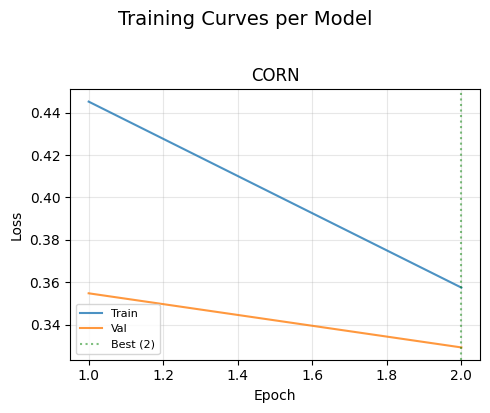


Model             Best epoch   Train loss     Val loss        Gap    LR(applied)               LR(source)
------------------------------------------------------------------------------------------------------------
CORN                2/2           0.3575       0.3294    -0.0282          0.001  explicit_model_override


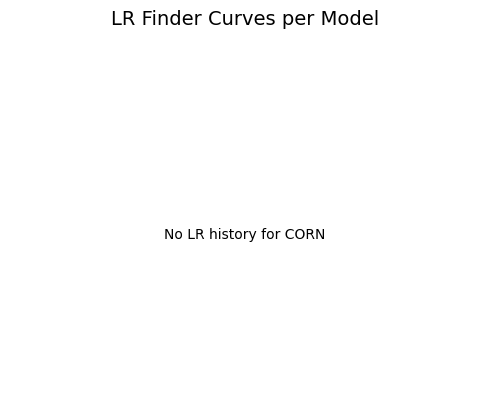

In [19]:
# Cell 3e - Training curves + LR finder curves (one subplot per model)
n_models = len(trained_models)
if n_models == 0:
    print("No models trained. Check training loop logs above.")
else:
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)
    axes = axes.flatten()

    for idx, (name, result) in enumerate(trained_models.items()):
        ax = axes[idx]
        history = result["history"]
        best_ep = result["best_epoch"]
        epochs_range = range(1, len(history["train_loss"]) + 1)

        ax.plot(epochs_range, history["train_loss"], label="Train", alpha=0.8)
        ax.plot(epochs_range, history["val_loss"], label="Val", alpha=0.8)
        if len(history["train_loss"]) > 0:
            ax.axvline(
                best_ep + 1,
                color="green",
                linestyle=":",
                alpha=0.5,
                label=f"Best ({best_ep + 1})",
            )
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Loss")
        ax.set_title(f"{name}")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

    plt.suptitle("Training Curves per Model", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

    # Summary table
    print()
    print(
        f"{'Model':<15s} {'Best epoch':>12s} {'Train loss':>12s} {'Val loss':>12s} {'Gap':>10s} {'LR(applied)':>14s} {'LR(source)':>24s}"
    )
    print("-" * 108)
    for name, result in trained_models.items():
        h = result["history"]
        be = result["best_epoch"]
        n_ep = len(h["train_loss"])
        if n_ep == 0:
            print(
                f"{name:<15s} {'N/A':>12s} {'N/A':>12s} {'N/A':>12s} {'N/A':>10s} {'N/A':>14s} {'N/A':>24s}"
            )
            continue
        tl = h["train_loss"][be]
        vl = h["val_loss"][be]
        gap = vl - tl
        lr_applied = result.get("learning_rate_applied", float("nan"))
        lr_source = result.get(
            "learning_rate_source",
            result.get("lr_finder", {}).get("lr_selected_source", "N/A"),
        )
        print(
            f"{name:<15s} {be + 1:>5d}/{n_ep:<5d} {tl:>12.4f} {vl:>12.4f} {gap:>+10.4f} {lr_applied:>14.6g} {str(lr_source):>24s}"
        )

    # LR finder curves
    fig, axes = plt.subplots(1, n_models, figsize=(5 * n_models, 4), squeeze=False)
    axes = axes.flatten()

    for idx, (name, result) in enumerate(trained_models.items()):
        ax = axes[idx]
        lr_meta = result.get("lr_finder", {})
        history_path_str = lr_meta.get("artifacts", {}).get("history_path")
        history_path = Path(history_path_str) if history_path_str else None

        if history_path is None or not history_path.exists():
            ax.text(
                0.5,
                0.5,
                f"No LR history for {name}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        history_json = json.loads(history_path.read_text())
        lrs = history_json.get("learning_rate", [])
        losses = history_json.get("loss", [])

        if not lrs or not losses:
            ax.text(
                0.5,
                0.5,
                f"No valid LR points for {name}",
                ha="center",
                va="center",
                transform=ax.transAxes,
            )
            ax.set_axis_off()
            continue

        ax.plot(lrs, losses, linewidth=1.8)
        ax.set_xscale("log")
        ax.set_xlabel("Learning Rate")
        ax.set_ylabel("Loss")
        ax.set_title(f"{name} LR Finder")
        ax.grid(True, alpha=0.3)

        lr_steep = history_json.get("suggestions", {}).get("lr_steep")
        lr_valley = history_json.get("suggestions", {}).get("lr_valley")
        lr_selected = result.get("learning_rate_applied")
        if lr_steep is not None:
            ax.axvline(
                lr_steep,
                color="tab:orange",
                linestyle="--",
                label=f"lr_steep={lr_steep:.2e}",
            )
        if lr_valley is not None:
            ax.axvline(
                lr_valley,
                color="tab:green",
                linestyle=":",
                label=f"lr_valley={lr_valley:.2e}",
            )
        if lr_selected is not None:
            ax.axvline(
                lr_selected,
                color="tab:red",
                linestyle="-.",
                label=f"selected={lr_selected:.2e}",
            )
        ax.legend(fontsize=8)

    plt.suptitle("LR Finder Curves per Model", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Section 4: Evaluation Dashboard (Issues #10, #11)


**Issue #10 — Class Imbalance:** Does the model predict only neutrals?

This section provides confusion matrices and prediction distributions to diagnose class imbalance and hedging behavior.

In [20]:
# Cell 4a - Evaluate all models with MC Dropout uncertainty
all_results = {}
model_health = {}

for name, result in trained_models.items():
    model = result["model"]
    artifact_dir = Path(result["artifact_dir"])
    artifact_paths = dict(result.get("artifact_paths", {}))

    print(f"\n{'=' * 70}")
    print(f"Evaluating {name} with MC Dropout uncertainty...")
    print(f"{'=' * 70}")

    val_eval_result = evaluate_with_uncertainty(
        model,
        val_loader,
        n_mc_samples=CONFIG["mc_dropout_samples"],
        device=device,
        include_ordinal_metrics=True,
        include_raw_outputs=True,
    )
    eval_result = evaluate_with_uncertainty(
        model,
        test_loader,
        n_mc_samples=CONFIG["mc_dropout_samples"],
        device=device,
        include_ordinal_metrics=True,
        include_raw_outputs=True,
    )
    all_results[name] = eval_result

    val_output_path = artifact_dir / "selected_validation_outputs.parquet"
    test_output_path = artifact_dir / "selected_test_outputs.parquet"
    export_ordinal_output_artifact(
        val_eval_result,
        val_loader,
        val_output_path,
        split="val",
        model_name=name,
    )
    export_ordinal_output_artifact(
        eval_result,
        test_loader,
        test_output_path,
        split="test",
        model_name=name,
    )
    artifact_paths.update(
        {
            "validation_outputs": str(val_output_path),
            "test_outputs": str(test_output_path),
        }
    )
    result["artifact_paths"] = artifact_paths

    print(f"\n{format_results_table(eval_result)}")
    print(
        f"Exported selected-checkpoint outputs to {val_output_path} and {test_output_path}"
    )

    preds = eval_result["predictions"]
    qwk_mean = float(eval_result.get("qwk_mean", float("nan")))
    spearman_mean = float(eval_result.get("spearman_mean", float("nan")))
    calibration_global = float(
        eval_result["calibration"].get("error_uncertainty_correlation", float("nan"))
    )
    mean_uncertainty = float(
        eval_result["calibration"].get("mean_uncertainty", float("nan"))
    )
    hedging_mean = float(eval_result.get("hedging_mean", float("nan")))
    qwk_nan_dims_count = int(eval_result.get("qwk_nan_dims_count", 0))
    prediction_std = float(np.std(preds))

    fail_reasons = []
    if not np.isfinite(qwk_mean):
        fail_reasons.append("qwk_nan")
    if qwk_nan_dims_count > 0:
        fail_reasons.append("qwk_nan_dims")
    if not np.isfinite(spearman_mean):
        fail_reasons.append("spearman_nan")
    if mean_uncertainty < 1e-6:
        fail_reasons.append("uncertainty_collapse")
    if np.isfinite(hedging_mean) and hedging_mean >= 0.98:
        fail_reasons.append("hedging_collapse")
    if np.isfinite(calibration_global) and calibration_global < 0:
        fail_reasons.append("negative_calibration")
    if prediction_std < 1e-6:
        fail_reasons.append("prediction_constant")

    model_health[name] = {
        "qwk_mean": qwk_mean,
        "qwk_nan_dims_count": qwk_nan_dims_count,
        "spearman_mean": spearman_mean,
        "calibration_global": calibration_global,
        "mean_uncertainty": mean_uncertainty,
        "hedging_mean": hedging_mean,
        "prediction_std": prediction_std,
        "fail_reasons": fail_reasons,
    }

if not all_results:
    raise RuntimeError("No models were evaluated successfully.")

print(f"\n{'=' * 70}")
print("Model Health Check")
print(f"{'=' * 70}")
print(
    f"{'Model':<15s} {'QWK':>8s} {'QWK NaNs':>10s} {'Spearman':>10s} {'Cal':>8s} {'Mean unc.':>10s} {'Hedging':>10s} {'Pred std':>10s}  Status"
)
print("-" * 118)
for name, health in model_health.items():
    qwk_str = f"{health['qwk_mean']:.3f}" if np.isfinite(health["qwk_mean"]) else "N/A"
    sp_str = (
        f"{health['spearman_mean']:.3f}"
        if np.isfinite(health["spearman_mean"])
        else "N/A"
    )
    cal_str = (
        f"{health['calibration_global']:+.3f}"
        if np.isfinite(health["calibration_global"])
        else "N/A"
    )
    status = (
        "OK"
        if not health["fail_reasons"]
        else f"EXCLUDE ({', '.join(health['fail_reasons'])})"
    )
    print(
        f"{name:<15s} {qwk_str:>8s} {health['qwk_nan_dims_count']:>10d} {sp_str:>10s} "
        f"{cal_str:>8s} {health['mean_uncertainty']:>10.4f} {health['hedging_mean']:>9.1%} "
        f"{health['prediction_std']:>10.6f}  {status}"
    )

rankable_results = {
    name: all_results[name]
    for name, health in model_health.items()
    if not health["fail_reasons"]
}
excluded_models = [
    name for name, health in model_health.items() if health["fail_reasons"]
]

if not rankable_results:
    print(
        "\nWARNING: All models flagged as degenerate; using all_results for comparison tables."
    )
    rankable_results = dict(all_results)
elif excluded_models:
    print(f"\nExcluding from ranking/comparison: {excluded_models}")



Evaluating CORN with MC Dropout uncertainty...



Dimension                   MAE   Spearman   Accuracy        QWK
----------------------------------------------------------------
self_direction           0.4480      0.283     56.56%      0.129
stimulation              0.1176        N/A     88.24%        N/A
hedonism                 0.1719        N/A     82.81%        N/A
achievement              0.2805      0.285     71.04%        N/A
power                    0.1602     -0.344     84.62%     -0.057
security                 0.2353        N/A     76.47%        N/A
conformity               0.3729      0.143     62.44%        N/A
tradition                0.2796      0.114     71.95%        N/A
benevolence              0.3864      0.236     61.54%      0.068
universalism             0.1186     -0.187     88.24%        N/A
----------------------------------------------------------------
MEAN                     0.2571      0.076     74.39%      0.047

Calibration:
  Error-uncertainty correlation: 0.284
  Mean uncertainty: 0.0232
  Quality

Model Comparison (rankable models):
shape: (1, 6)
┌───────┬────────┬──────────┬────────┬──────────┬─────────────┐
│ Model ┆ MAE    ┆ Accuracy ┆ QWK    ┆ Spearman ┆ Calibration │
│ ---   ┆ ---    ┆ ---      ┆ ---    ┆ ---      ┆ ---         │
│ str   ┆ f64    ┆ f64      ┆ f64    ┆ f64      ┆ f64         │
╞═══════╪════════╪══════════╪════════╪══════════╪═════════════╡
│ CORN  ┆ 0.2571 ┆ 0.7439   ┆ 0.0467 ┆ 0.0756   ┆ 0.2839      │
└───────┴────────┴──────────┴────────┴──────────┴─────────────┘
Excluded models (degenerate): ['CORN']


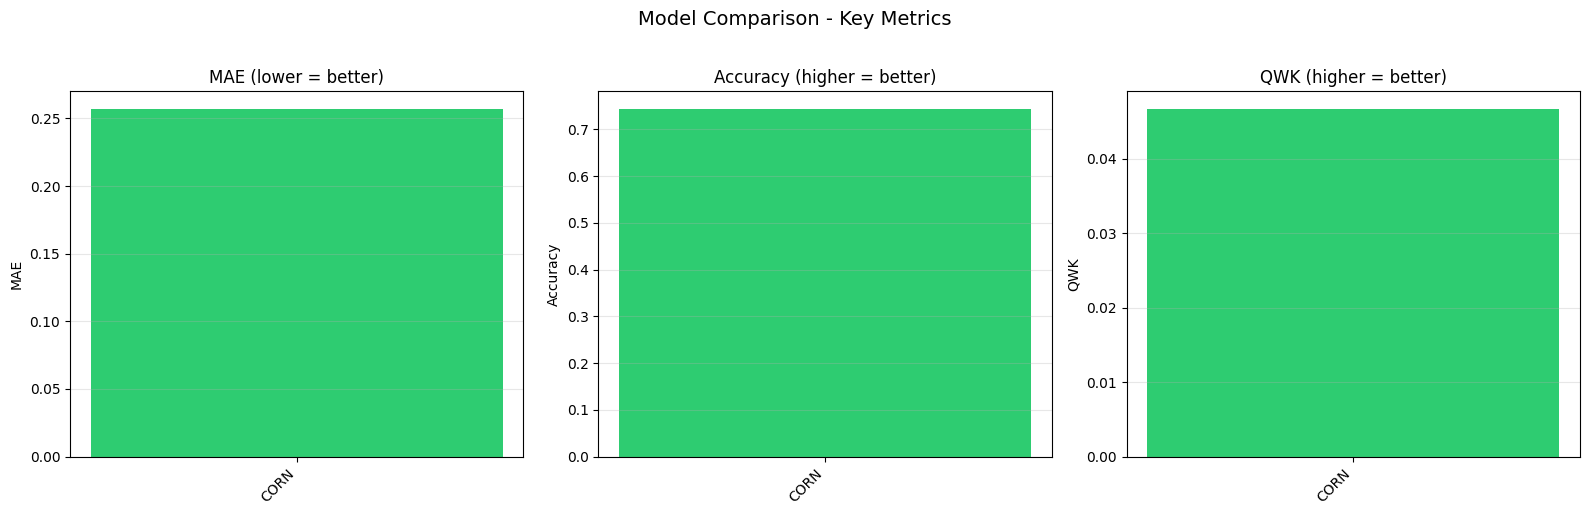

In [21]:
# Cell 4b - Model comparison table and grouped bar chart

# Build comparison DataFrame from rankable models only
rows = []
for name, res in rankable_results.items():
    rows.append(
        {
            "Model": name,
            "MAE": round(res["mae_mean"], 4),
            "Accuracy": round(res["accuracy_mean"], 4),
            "QWK": round(res["qwk_mean"], 4),
            "Spearman": round(res["spearman_mean"], 4),
            "Calibration": round(
                res["calibration"]["error_uncertainty_correlation"], 4
            ),
        }
    )

if not rows:
    raise RuntimeError("No rankable models available for comparison.")

comparison_df = pl.DataFrame(rows)
print("Model Comparison (rankable models):")
print(comparison_df)
if excluded_models:
    print(f"Excluded models (degenerate): {excluded_models}")

# Grouped bar chart for 3 key metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
model_names = comparison_df["Model"].to_list()
x = np.arange(len(model_names))
width = 0.6

# MAE (lower is better)
mae_vals = comparison_df["MAE"].to_list()
best_mae = np.nanmin(mae_vals) if np.any(np.isfinite(mae_vals)) else None
colors = [
    "#2ecc71"
    if (best_mae is not None and np.isfinite(v) and v == best_mae)
    else "#3498db"
    for v in mae_vals
]
axes[0].bar(x, mae_vals, width, color=colors)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=45, ha="right")
axes[0].set_ylabel("MAE")
axes[0].set_title("MAE (lower = better)")
axes[0].grid(True, alpha=0.3, axis="y")

# Accuracy (higher is better)
acc_vals = comparison_df["Accuracy"].to_list()
best_acc = np.nanmax(acc_vals) if np.any(np.isfinite(acc_vals)) else None
colors = [
    "#2ecc71"
    if (best_acc is not None and np.isfinite(v) and v == best_acc)
    else "#3498db"
    for v in acc_vals
]
axes[1].bar(x, acc_vals, width, color=colors)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=45, ha="right")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy (higher = better)")
axes[1].grid(True, alpha=0.3, axis="y")

# QWK (higher is better)
qwk_vals = comparison_df["QWK"].to_list()
best_qwk = np.nanmax(qwk_vals) if np.any(np.isfinite(qwk_vals)) else None
colors = [
    "#2ecc71"
    if (best_qwk is not None and np.isfinite(v) and v == best_qwk)
    else "#3498db"
    for v in qwk_vals
]
axes[2].bar(x, qwk_vals, width, color=colors)
axes[2].set_xticks(x)
axes[2].set_xticklabels(model_names, rotation=45, ha="right")
axes[2].set_ylabel("QWK")
axes[2].set_title("QWK (higher = better)")
axes[2].grid(True, alpha=0.3, axis="y")

plt.suptitle("Model Comparison - Key Metrics", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


Best model for confusion matrix: CORN (QWK)


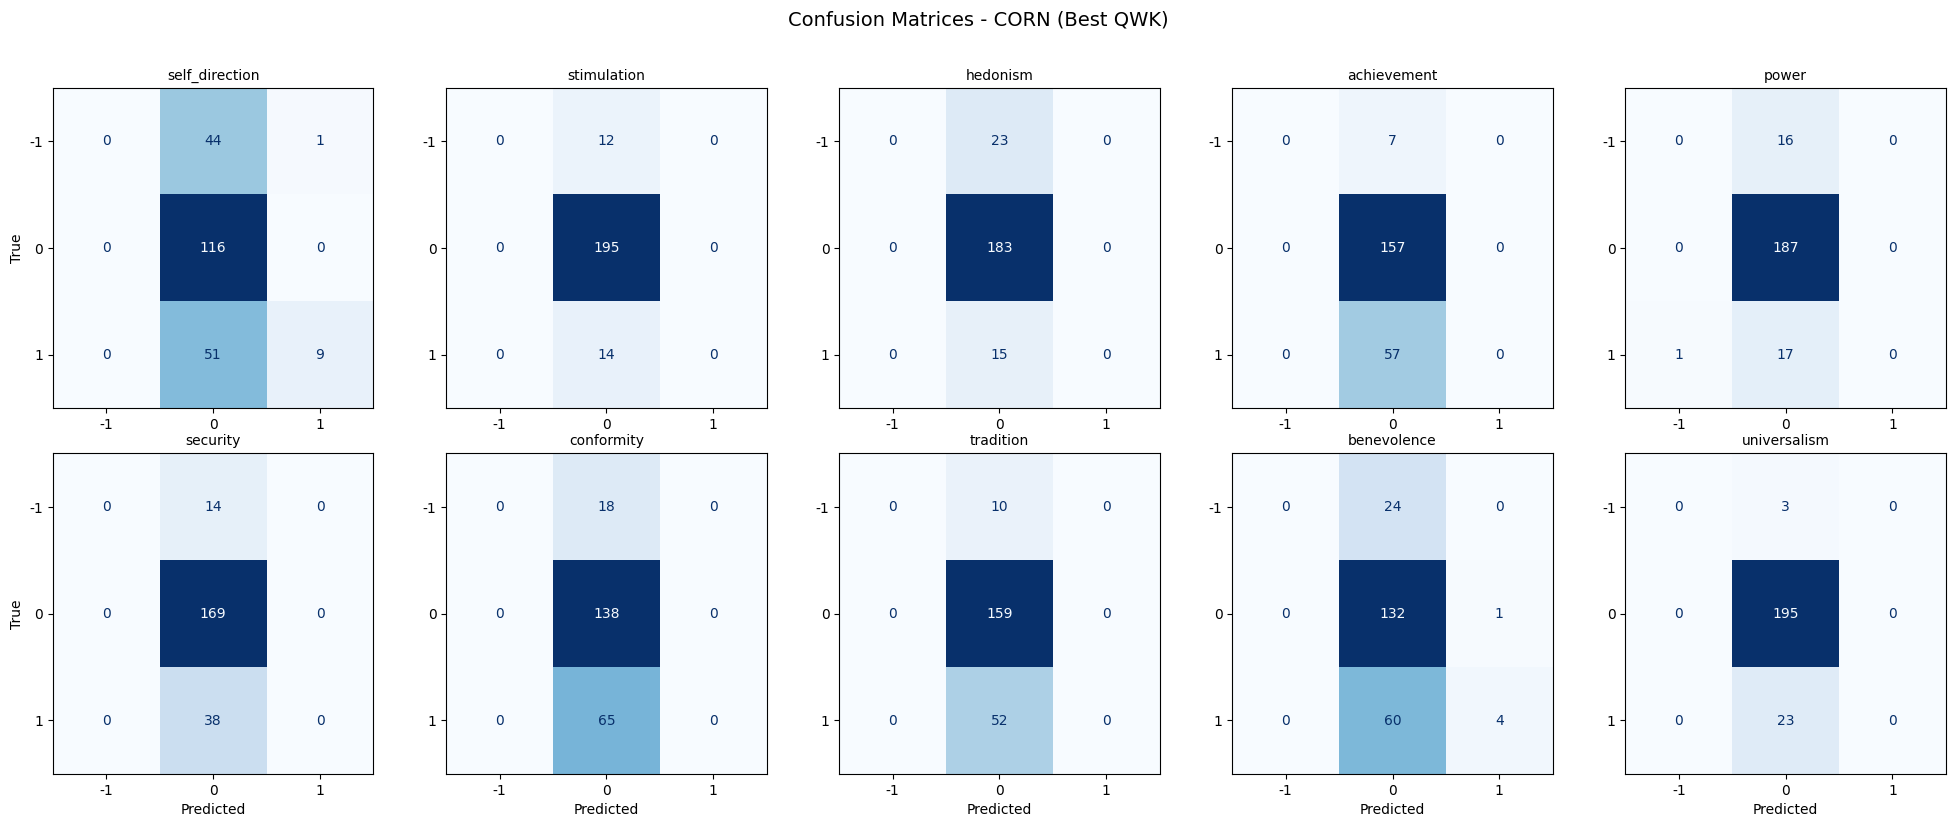


Per-Class Recall Across Models (aggregated over 10 dimensions)

Model            Recall -1   Recall 0  Recall +1   Mean minority
--------------------------------------------------------------
CORN                  0.0%      99.9%       2.1%            1.1%


In [22]:
# Cell 4c - Confusion matrices for best model + per-class recall

# Find best model by finite QWK among rankable models
qwk_candidates = {
    n: rankable_results[n]["qwk_mean"]
    for n in rankable_results
    if np.isfinite(rankable_results[n].get("qwk_mean", float("nan")))
}
if qwk_candidates:
    best_model_name = max(qwk_candidates, key=qwk_candidates.get)
    best_model_reason = "QWK"
else:
    best_model_name = max(
        rankable_results, key=lambda n: rankable_results[n]["accuracy_mean"]
    )
    best_model_reason = "Accuracy fallback"

print(f"Best model for confusion matrix: {best_model_name} ({best_model_reason})")

# Plot confusion matrices for best model (2x5 grid)
res = rankable_results[best_model_name]
pred_cls = discretize_predictions(res["predictions"])
target_cls = discretize_predictions(res["targets"])

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes_flat = axes.flatten()
for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    cm = confusion_matrix(target_cls[:, i], pred_cls[:, i], labels=[-1, 0, 1])
    disp = ConfusionMatrixDisplay(cm, display_labels=[-1, 0, 1])
    disp.plot(ax=axes_flat[i], cmap="Blues", colorbar=False)
    axes_flat[i].set_title(dim, fontsize=10)
    axes_flat[i].set_xlabel("Predicted" if i >= 5 else "")
    axes_flat[i].set_ylabel("True" if i % 5 == 0 else "")
plt.suptitle(
    f"Confusion Matrices - {best_model_name} (Best {best_model_reason})",
    fontsize=14,
    y=1.02,
)
plt.tight_layout()
plt.show()

# Per-class recall table across all models
print(f"\n{'=' * 70}")
print("Per-Class Recall Across Models (aggregated over 10 dimensions)")
print(f"{'=' * 70}")
print(
    f"\n{'Model':<15s} {'Recall -1':>10s} {'Recall 0':>10s} "
    f"{'Recall +1':>10s} {'Mean minority':>15s}"
)
print("-" * 62)

all_recall_data = {}
for model_name, res in all_results.items():
    recall_minus1 = float(res.get("recall_minus1", float("nan")))
    recall_zero = float(res.get("recall_zero", float("nan")))
    recall_plus1 = float(res.get("recall_plus1", float("nan")))
    mean_minority = float(res.get("minority_recall_mean", float("nan")))

    all_recall_data[model_name] = {
        "recall_minus1": recall_minus1,
        "recall_zero": recall_zero,
        "recall_plus1": recall_plus1,
        "mean_minority": mean_minority,
    }

    print(
        f"{model_name:<15s} {recall_minus1:>10.1%} {recall_zero:>10.1%} "
        f"{recall_plus1:>10.1%} {mean_minority:>15.1%}"
    )


In [23]:
# Cell 4d — Hedging comparison: % predictions in [-0.3, 0.3] per model

print(f"{'=' * (20 + 13 * len(all_results))}")
print("Hedging Comparison — % predictions in [-0.3, 0.3]")
print(f"{'=' * (20 + 13 * len(all_results))}")

print(f"\n{'Dimension':<20s}", end="")
for name in all_results:
    print(f" {name:>12s}", end="")
print()
print("-" * (20 + 13 * len(all_results)))

all_hedging = {}
for name, res in all_results.items():
    near_zero = np.array(
        [res["hedging_per_dim"][dim] for dim in SCHWARTZ_VALUE_ORDER],
        dtype=float,
    )
    all_hedging[name] = near_zero

for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    print(f"{dim:<20s}", end="")
    for name in all_results:
        val = all_hedging[name][i]
        flag = "*" if val > 0.8 else " "
        print(f" {val:>11.1%}{flag}", end="")
    print()

print(f"{'MEAN':<20s}", end="")
for name in all_results:
    mean_val = all_hedging[name].mean()
    print(f" {mean_val:>11.1%} ", end="")
print()
print(f"\n* = hedging (>80% near zero)")

Hedging Comparison — % predictions in [-0.3, 0.3]

Dimension                    CORN
---------------------------------
self_direction             88.7%*
stimulation               100.0%*
hedonism                  100.0%*
achievement                98.6%*
power                      99.1%*
security                  100.0%*
conformity                 99.5%*
tradition                 100.0%*
benevolence                93.7%*
universalism              100.0%*
MEAN                       98.0% 

* = hedging (>80% near zero)


# Section 5: Calibration Analysis (Issue #9)

**Issue 9 — Uncertainty Calibration:** Does higher MC Dropout uncertainty correspond to higher actual error? If not, uncertainty estimates are unreliable.

In [24]:
# Cell 5a - Per-dimension error-uncertainty correlation across all models

print(f"{'=' * (20 + 13 * len(all_results))}")
print("Calibration Analysis - Error-Uncertainty Spearman Correlation")
print(f"{'=' * (20 + 13 * len(all_results))}")

print(f"\n{'Dimension':<20s}", end="")
for name in all_results:
    print(f" {name:>12s}", end="")
print()
print("-" * (20 + 13 * len(all_results)))

all_calibration = {}
for name, res in all_results.items():
    calibration = res["calibration"]
    all_calibration[name] = {
        "per_dim": calibration["per_dim"],
        "global": calibration["error_uncertainty_correlation"],
        "positive_count": calibration["positive_count"],
        "mean_uncertainty": calibration["mean_uncertainty"],
    }

for i, dim in enumerate(SCHWARTZ_VALUE_ORDER):
    print(f"{dim:<20s}", end="")
    for name in all_results:
        corr = all_calibration[name]["per_dim"][dim]
        corr_str = f"{corr:+.3f}" if not np.isnan(corr) else "N/A"
        print(f" {corr_str:>12s}", end="")
    print()

print(f"\n{'Global correlation':<20s}", end="")
for name in all_results:
    corr = all_calibration[name]["global"]
    corr_str = f"{corr:+.3f}" if np.isfinite(corr) else "N/A"
    print(f" {corr_str:>12s}", end="")
print()
print(f"{'Positive dims':<20s}", end="")
for name in all_results:
    print(f" {all_calibration[name]['positive_count']:>10d}/10", end="")
print()
print(f"{'Mean uncertainty':<20s}", end="")
for name in all_results:
    print(f" {all_calibration[name]['mean_uncertainty']:>12.4f}", end="")
print()


Calibration Analysis - Error-Uncertainty Spearman Correlation

Dimension                    CORN
---------------------------------
self_direction             +0.272
stimulation                   N/A
hedonism                      N/A
achievement                +0.224
power                      +0.369
security                      N/A
conformity                 +0.127
tradition                  +0.066
benevolence                +0.220
universalism               +0.208

Global correlation         +0.284
Positive dims                 7/10
Mean uncertainty           0.0232


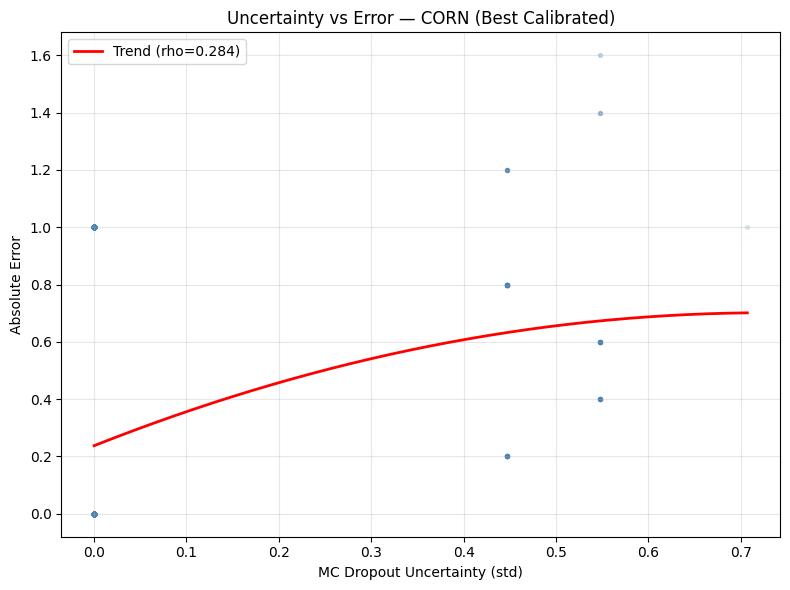

In [25]:
# Cell 5b — Calibration scatter for best-calibrated model
best_cal_model = max(all_calibration, key=lambda n: all_calibration[n]["global"])
res = all_results[best_cal_model]

unc_flat = res["uncertainties"].flatten()
err_flat = np.abs(res["predictions"] - res["targets"]).flatten()
global_corr = all_calibration[best_cal_model]["global"]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(unc_flat, err_flat, alpha=0.15, s=8, color="steelblue")

finite_mask = np.isfinite(unc_flat) & np.isfinite(err_flat)
if finite_mask.sum() > 3:
    z = np.polyfit(unc_flat[finite_mask], err_flat[finite_mask], 2)
    p = np.poly1d(z)
    x_line = np.linspace(unc_flat[finite_mask].min(), unc_flat[finite_mask].max(), 200)
    ax.plot(
        x_line, p(x_line), "r-", linewidth=2, label=f"Trend (rho={global_corr:.3f})"
    )

ax.set_xlabel("MC Dropout Uncertainty (std)")
ax.set_ylabel("Absolute Error")
ax.set_title(f"Uncertainty vs Error — {best_cal_model} (Best Calibrated)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Section 6: Issue Scorecard

Summary of all diagnostics for before/after comparison.

In [26]:
# Cell 6.1 - Multi-model scorecard
print("=" * 90)
print("DIAGNOSTIC SCORECARD - MULTI-MODEL COMPARISON")
print("=" * 90)

# Issue #9 - Calibration
print(f"\n{'--- #9 Calibration ':-<90s}")
print(
    f"  {'Model':<15s} {'Global corr':>12s} {'Positive dims':>15s} {'Mean unc.':>12s}"
)
print(f"  {'-' * 56}")
for name in all_results:
    cal = all_calibration[name]
    global_corr = cal["global"]
    corr_str = f"{global_corr:+.3f}" if np.isfinite(global_corr) else "N/A"
    print(
        f"  {name:<15s} {corr_str:>12s} "
        f"{cal['positive_count']:>13d}/10 {cal['mean_uncertainty']:>12.4f}"
    )
print(f"  Guidance: >0.1 useful, <0 dangerous (uncertainty misleads)")

# Issue #10 - Imbalance
print(f"\n{'--- #10 Imbalance ':-<90s}")
print(f"  Overall neutral %: {neutral_pct:.1f}%")
print(
    f"  Flagged dims (>10x imbalance): {sum(1 for r in imbalance_ratios if r > 10)}/10"
)
print(f"  Unlearnable dims: {unlearnable if unlearnable else 'None'}")
print(
    f"\n  {'Model':<15s} {'Recall -1':>10s} {'Recall +1':>10s} {'Mean minority':>15s}"
)
print(f"  {'-' * 52}")
for name in all_results:
    rd = all_recall_data[name]
    print(
        f"  {name:<15s} {rd['recall_minus1']:>10.1%} "
        f"{rd['recall_plus1']:>10.1%} {rd['mean_minority']:>15.1%}"
    )
print(f"  Guidance: Minority recall near 0% = model ignores rare classes")

# Ordinal quality
print(f"\n{'--- Ordinal Quality ':-<90s}")
print(
    f"  {'Model':<15s} {'QWK':>8s} {'Hedging %':>10s} {'QWK NaNs':>10s} {'Status':>12s}"
)
print(f"  {'-' * 64}")
for name in all_results:
    qwk = all_results[name]["qwk_mean"]
    hedge = all_hedging[name].mean() * 100
    qwk_nan_dims = all_results[name].get("qwk_nan_dims_count", 0)
    qwk_str = f"{qwk:.3f}" if np.isfinite(qwk) else "N/A"
    status = "EXCLUDED" if name in excluded_models else "OK"
    print(
        f"  {name:<15s} {qwk_str:>8s} {hedge:>9.1f}% {qwk_nan_dims:>10d} {status:>12s}"
    )
print(f"  Guidance: High hedging % = neutral collapse; QWK near 0 = chance")

# Selection / overfitting
print(f"\n{'--- Selection / Overfitting ':-<90s}")
print(
    f"  {'Model':<15s} {'Sel epoch':>10s} {'Sel val':>12s} {'Gap':>12s} {'QWK':>8s} {'Source':>24s}"
)
print(f"  {'-' * 86}")
for name, result in trained_models.items():
    h = result["history"]
    be = result["best_epoch"]
    n_ep = len(h["train_loss"])
    selected = result.get("selected_candidate", {})
    sel_val = selected.get("val_loss", result.get("best_val_loss", float("nan")))
    sel_qwk = selected.get("qwk_mean", float("nan"))
    gap = (
        h["val_loss"][be] - h["train_loss"][be]
        if len(h["train_loss"]) > be
        else float("nan")
    )
    sel_qwk_str = f"{sel_qwk:.3f}" if np.isfinite(sel_qwk) else "N/A"
    print(
        f"  {name:<15s} {be + 1:>5d}/{n_ep:<4d} {sel_val:>12.4f} {gap:>+12.4f} "
        f"{sel_qwk_str:>8s} {result.get('selection_source', 'unknown'):>24s}"
    )
print(
    "  Guidance: Selected checkpoints should be finite-QWK and non-negative-calibration; large positive gaps still suggest overfitting"
)

# Issue #14 - Embedding (model-independent)
print(f"\n{'--- #14 Embedding ':-<90s}")
print(f"  Encoder: {CONFIG['encoder_model']}")
print(f"  Truncated entries: {pct_truncated:.1f}%")
print(
    f"  Guidance: Gap <0.1 = poor discrimination; >5% truncation = losing information"
)


def _best_finite(results_dict, metric_name, mode="max"):
    values = []
    for model_name, result in results_dict.items():
        value = result.get(metric_name, float("nan"))
        if np.isfinite(value):
            values.append((model_name, value))

    if not values:
        return None, float("nan")

    if mode == "max":
        return max(values, key=lambda item: item[1])
    if mode == "min":
        return min(values, key=lambda item: item[1])
    raise ValueError(f"Unsupported mode: {mode}")


# Winner summary (rankable only)
print(f"\n{'--- Winner Summary (Rankable Models) ':-<90s}")
if not rankable_results:
    print("  No rankable models after health checks.")
else:
    best_qwk_model, best_qwk_value = _best_finite(
        rankable_results, "qwk_mean", mode="max"
    )
    best_acc_model, best_acc_value = _best_finite(
        rankable_results, "accuracy_mean", mode="max"
    )
    best_mae_model, best_mae_value = _best_finite(
        rankable_results, "mae_mean", mode="min"
    )

    rankable_calibration = {
        name: all_calibration[name]
        for name in rankable_results
        if name in all_calibration
    }
    cal_values = [
        (name, meta["global"])
        for name, meta in rankable_calibration.items()
        if np.isfinite(meta["global"])
    ]
    if cal_values:
        best_cal_model, best_cal_value = max(cal_values, key=lambda item: item[1])
    else:
        best_cal_model, best_cal_value = None, float("nan")

    print(
        f"  Best by QWK:         {best_qwk_model if best_qwk_model else 'N/A':<15s} "
        f"({best_qwk_value:.3f})"
        if np.isfinite(best_qwk_value)
        else "  Best by QWK:         N/A"
    )
    print(
        f"  Best by Accuracy:    {best_acc_model if best_acc_model else 'N/A':<15s} "
        f"({best_acc_value:.2%})"
        if np.isfinite(best_acc_value)
        else "  Best by Accuracy:    N/A"
    )
    print(
        f"  Best by MAE:         {best_mae_model if best_mae_model else 'N/A':<15s} "
        f"({best_mae_value:.4f})"
        if np.isfinite(best_mae_value)
        else "  Best by MAE:         N/A"
    )
    print(
        f"  Best by Calibration: {best_cal_model if best_cal_model else 'N/A':<15s} "
        f"({best_cal_value:.3f})"
        if np.isfinite(best_cal_value)
        else "  Best by Calibration: N/A"
    )

if excluded_models:
    print(f"\n  Excluded from ranking due to degeneracy: {excluded_models}")

print(f"\n{'=' * 90}")


DIAGNOSTIC SCORECARD - MULTI-MODEL COMPARISON

--- #9 Calibration -----------------------------------------------------------------------
  Model            Global corr   Positive dims    Mean unc.
  --------------------------------------------------------
  CORN                  +0.284             7/10       0.0232
  Guidance: >0.1 useful, <0 dangerous (uncertainty misleads)

--- #10 Imbalance ------------------------------------------------------------------------
  Overall neutral %: 74.8%
  Flagged dims (>10x imbalance): 5/10
  Unlearnable dims: None

  Model            Recall -1  Recall +1   Mean minority
  ----------------------------------------------------
  CORN                  0.0%       2.1%            1.1%
  Guidance: Minority recall near 0% = model ignores rare classes

--- Ordinal Quality ----------------------------------------------------------------------
  Model                QWK  Hedging %   QWK NaNs       Status
  --------------------------------------------------

# Section 7: Experiment Logging

In [27]:
# Cell 6.2 - CDW-CE watch gates

print("=" * 90)
print("CDW-CE WATCH GATES")
print("=" * 90)
print("Targets: recall_minus1 > 0.15 AND QWK > 0.40")

watch_rows = []
for model_name, result in all_results.items():
    qwk = float(result.get("qwk_mean", float("nan")))
    recall_minus1 = float(all_recall_data[model_name]["recall_minus1"])

    pass_recall = recall_minus1 > 0.15
    pass_qwk = bool(np.isfinite(qwk) and qwk > 0.40)
    pass_joint = pass_recall and pass_qwk

    watch_rows.append(
        {
            "Model": model_name,
            "QWK": round(qwk, 4) if np.isfinite(qwk) else None,
            "RecallMinus1": round(recall_minus1, 4),
            "PassQWK": pass_qwk,
            "PassRecallMinus1": pass_recall,
            "PassJoint": pass_joint,
        }
    )

watch_df = pl.DataFrame(watch_rows).sort("Model")
print(watch_df)

passed = [row["Model"] for row in watch_rows if row["PassJoint"]]
if passed:
    print()
    print(f"PASS: Joint gate met by {passed}")
else:
    best_candidate = max(
        watch_rows,
        key=lambda row: (
            row["PassQWK"],
            row["RecallMinus1"],
            row["QWK"] if row["QWK"] is not None else float("-inf"),
        ),
    )
    print()
    print("NO JOINT PASS: no model met both thresholds.")
    print(
        "Best candidate by (PassQWK, RecallMinus1, QWK): "
        f"{best_candidate['Model']} "
        f"(QWK={best_candidate['QWK']}, RecallMinus1={best_candidate['RecallMinus1']})"
    )


CDW-CE WATCH GATES
Targets: recall_minus1 > 0.15 AND QWK > 0.40
shape: (1, 6)
┌───────┬────────┬──────────────┬─────────┬──────────────────┬───────────┐
│ Model ┆ QWK    ┆ RecallMinus1 ┆ PassQWK ┆ PassRecallMinus1 ┆ PassJoint │
│ ---   ┆ ---    ┆ ---          ┆ ---     ┆ ---              ┆ ---       │
│ str   ┆ f64    ┆ f64          ┆ bool    ┆ bool             ┆ bool      │
╞═══════╪════════╪══════════════╪═════════╪══════════════════╪═══════════╡
│ CORN  ┆ 0.0467 ┆ 0.0          ┆ false   ┆ false            ┆ false     │
└───────┴────────┴──────────────┴─────────┴──────────────────┴───────────┘

NO JOINT PASS: no model met both thresholds.
Best candidate by (PassQWK, RecallMinus1, QWK): CORN (QWK=0.0467, RecallMinus1=0.0)


In [28]:
OBSERVATIONS = ""  # Leave empty; experiment-review skill will generate observations

from src.vif.experiment_logger import log_experiment_run

if CONFIG.get("skip_experiment_logging", False):
    logged_paths = []
    print("Skipping experiment logging (skip_experiment_logging=True)")
else:
    logged_paths = log_experiment_run(
        config=CONFIG,
        trained_models=trained_models,
        all_results=all_results,
        all_calibration=all_calibration,
        all_hedging=all_hedging,
        all_recall_data=all_recall_data,
        n_train=n_train,
        n_val=n_val,
        n_test=n_test,
        pct_truncated=pct_truncated,
        state_dim=state_encoder.state_dim,
        observations=OBSERVATIONS.strip(),
    )
    print()
    print(f"Logged {len(logged_paths)} experiments:")
    for entry in logged_paths:
        tag = "CREATED"
        print(f"  [{tag}] {entry['path']}  ({entry['run_id']})")

Skipping experiment logging (skip_experiment_logging=True)
